In [1]:
import numpy as np
from pyscf import gto, scf, cc

a = 2 # bond length in a cluster
d = 4 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'N'
unit = 'B'
basis = 'sto6g'
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis="sto6g",
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

stable = False
for i in range(10):
    print(f'mf stability test {i+1}')
    if not stable:
        mo_i, _, stable,_ = mf.stability(return_status=True)
        dm = mf.make_rdm1(mo_i,mf.mo_occ)
        mf.kernel(dm0=dm)
    elif stable:
        print(f'mf energy: {mf.e_tot}, stability {stable}')
        break

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

et = mycc.ccsd_t()
print(f"CCSD(T) = {mycc.e_tot+et}")

# CASCI E = -108.670551762995  E(CI) = -31.7781404613648  S^2 = 0.0000000

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-35-generic', version='#35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Thu Jun  4 18:50:40 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      uni

In [2]:
from pyscf.data import elements
from afqmc import mf_integral
nelec, norb, h0, h1, chol \
    = mf_integral.get_hamiltonian(mf, norb_frozen=elements.chemcore(mol), chol_cut=1e-5,)
print(f"nelec {nelec}")
print(f"norb  {norb}")

nelec [5, 5]
norb  8


In [28]:
print(f"alpha chol shape {chol[0].shape}")
print(f"beta chol shape  {chol[1].shape}")

alpha chol shape (8, 8)
beta chol shape  (8, 8)


In [3]:
from afqmc import cc_tools
t1, t2 = cc_tools.get_cc_amps(mycc)
ci1, ci2 = cc_tools.get_ci_amps(mycc)

In [30]:
print(f"t2ab shape {t2[1].shape}")
print(f"ci2ab shape {ci2[1].shape}")

t2ab shape (3, 5, 3)
ci2ab shape (3, 5, 3)


In [ ]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import opt_einsum as oe

def get_qmc_options(options=None):

    options["dt"] = options.get("dt", 0.005)
    options["eql_time"] = options.get("eql_time", 20)
    options["nwalker"] = options.get("nwalker", 300)
    options["nstep"] = options.get("nstep", 50)
    options["nsample"] = options.get("nsample", 500)
    options["max_error"] = options.get("max_error", 0.0)
    options["seed"] = options.get("seed", np.random.randint(1, int(1e6)))
    options["n_exp_terms"] = options.get("n_exp_terms",6)
    options["walker_type"] = options.get("walker_type", "rhf")
    options["trial"] = options.get("trial", "rhf")
    options["nwalker_batch"] = options.get("nwalker_batch", 1)
    options["nchol_chunk"] = options.get("nchol_chunk", 100)
    options["max_memory"] = options.get("max_memory", 2000) # MB
    options["mix_precision"] = options.get("mix_precision", True)

    print("\nQMC Parameters")
    for op in options:
        if options[op] is not None:
            print(f"{str(op):<15s} - {str(options[op]):>15s}")

    return options
        
def get_wave_data(nelec, 
                  norb,
                  mo_coeff=None, 
                  t1=None,
                  t2=None, 
                  ci1=None,
                  ci2=None,
                  ):
    # normalize to hashable python types
    nelec = tuple(int(x) for x in nelec)
    norb = (int(norb) if not isinstance(norb, (tuple, list))
            else tuple(int(x) for x in norb))
    
    wave_data = {}
    wave_data["nelec"] = nelec
    wave_data["norb"] = norb
    wave_data["t1"] = t1
    wave_data["t2"] = t2
    wave_data["ci1"] = ci1
    wave_data["ci2"] = ci2

    if isinstance(norb, int):
        if mo_coeff is None:
            mo_coeff = jnp.eye(norb)[:,:nelec[0]]
            wave_data["mo_coeff"] = mo_coeff
            wave_data["rdm1"] = jnp.array(wave_data["mo_coeff"] @ wave_data["mo_coeff"].T) * 2
    elif isinstance(norb, (tuple, list)):
        if mo_coeff is None:
            mo_coeff = (jnp.eye(norb)[:,:nelec[0]],
                        jnp.eye(norb)[:,:nelec[1]])
            wave_data["mo_coeff"] = mo_coeff
            wave_data["rdm1"] = (wave_data["mo_coeff"][0] @ wave_data["mo_coeff"][0].T,
                                 wave_data["mo_coeff"][1] @ wave_data["mo_coeff"][1].T)
    return wave_data


def r_propagation_intermediates(h0, h1, chol, rdm1, dt):

    mf_shifts = 1.0j * oe.contract("gpq,pq->g", chol, rdm1)
    h0_prop = - h0 - jnp.sum(mf_shifts**2) / 2.0
    v0 = 0.5 * oe.contract("gpr,gqr->pr", chol, chol, backend="jax")
    v1 = jnp.real(1.0j * oe.contract("g,gpq->pq", mf_shifts, chol, backend="jax"))
    h1_mod = h1 - v0 - v1
    exp_h1 = jnp.array(jsp.linalg.expm(-dt * h1_mod / 2.0))
    
    return mf_shifts, h0_prop, exp_h1

def u_propagation_intermediates(h0, h1, chol, rdm1, dt):

    mf_shift_a = 1.0j * oe.contract("gpq,pq->g", chol[0], rdm1[0])
    mf_shift_b = 1.0j * oe.contract("gpq,pq->g", chol[1], rdm1[1])
    mf_shifts = mf_shift_a + mf_shift_b
    h0_prop = - h0 - jnp.sum(mf_shifts**2) / 2.0
    # alpha
    v0_a = 0.5 * oe.contract("gpr,gqr->pr", chol[0], chol[0], backend="jax")
    # beta
    v0_b = 0.5 * oe.contract("gpr,gqr->pr", chol[1], chol[1], backend="jax")
    # alpha
    v1_a = jnp.real(1.0j * oe.contract("g,gpq->pq", mf_shifts, chol[0], backend="jax"))
    # beta
    v1_b = jnp.real(1.0j * oe.contract("g,gpq->pq", mf_shifts, chol[1], backend="jax"))
    h1_mod = (h1[0] - v0_a - v1_a, h1[1] - v0_b - v1_b)
    exp_h1 = (jnp.array(jsp.linalg.expm(-dt * h1_mod[0] / 2.0)),
              jnp.array(jsp.linalg.expm(-dt * h1_mod[1] / 2.0)))
    
    return mf_shifts, h0_prop, exp_h1

def propagation_intermediates(h0, h1, chol, rdm1, dt):
    if isinstance(h1, jax.Array) and isinstance(chol, jax.Array):
        return r_propagation_intermediates(h0, h1, chol, rdm1, dt)
    elif isinstance(h1, (tuple, list)) and isinstance(chol, (tuple, list)):
        return u_propagation_intermediates(h0, h1, chol, rdm1, dt)


def get_ham_data(h0, h1, chol, wave_data, options):
    ham_data = {}
    ham_data["h0"] = h0

    # mf_shifts, h0_prop, exp_h1 \
    #     = propagation_intermediates(h0, h1, chol, wave_data["rdm1"], options["dt"])
    # ham_data["mf_shifts"] = mf_shifts
    # ham_data["h0_prop"] = h0_prop
    # ham_data["exp_h1"] = exp_h1

    if isinstance(h1, jax.Array):
        ham_data["h1"] = (jnp.array(h1), jnp.array(h1))
        nchol = chol.shape[0]
        ham_data["nchol"] = nchol
        ham_data["chol"] = jnp.array(chol.reshape(nchol, -1))
    elif isinstance(h1, (tuple, list)):
        ham_data["h1"] = (jnp.array(h1[0]), jnp.array(h1[1]))
        assert chol[0].shape[0] == chol[1].shape[0]
        nchol = chol[0].shape[0]
        ham_data["nchol"] = nchol
        ham_data["chol"] = (jnp.array(chol[0].reshape(nchol, -1)),
                            jnp.array(chol[1].reshape(nchol, -1)))
    return ham_data

In [9]:
from jax import random

def init_prop_data(
    trial,
    wave_data: dict,
    ham_data: dict,
    options: dict,
) -> dict:
    prop_data = {}
    prop_data["n_killed_walkers"] = 0
    prop_data["key"] = random.PRNGKey(options["seed"])
    prop_data["weights"] = jnp.ones(options["n_walkers"])
    
    if isinstance(wave_data["mo_coeff"], jax.Array):
        prop_data["walkers"] = jnp.array([wave_data["mo_coeff"]]*options["n_walkers"], dtype=jnp.complex128)
    elif isinstance(wave_data["mo_coeff"], (tuple, list)):
        walkers_a = jnp.array([wave_data["mo_coeff"][0]]*options["n_walkers"], dtype=jnp.complex128)
        walkers_b = jnp.array([wave_data["mo_coeff"][1]]*options["n_walkers"], dtype=jnp.complex128)
        walkers = [walkers_a, walkers_b]
        prop_data["walkers"] = walkers

    energies = jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data))
    guide_olps = trial.calc_overlap(prop_data["walkers"], wave_data)
    trial_olps = trial.calc_trial_overlap(prop_data["walkers"], wave_data)
    olp_ratio = trial_olps / guide_olps
    weights_p = prop_data["weights"] * olp_ratio
    e_estimate = (jnp.sum(weights_p * energies) / jnp.sum(weights_p)).real
    prop_data["e_estimate"] = e_estimate
    prop_data["pop_control_ene_shift"] = e_estimate
    prop_data["overlaps"] = guide_olps
    return prop_data

In [42]:
options = {'eql_time': 10,
            'n_blocks': 1000,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'trial': 'pt2ccsd',
            }
options = get_qmc_options(options)
wave_data = get_wave_data(nelec, norb, t1=t1, t2=t2, ci1=ci1, ci2=ci2)
ham_data = get_ham_data(h0, h1, chol, wave_data, options)


QMC Parameters
eql_time        -              10
n_blocks        -            1000
n_walkers       -             300
max_error       -             0.0
mix_precision   -           False
seed            -              17
walker_type     -             rhf
trial           -         pt2ccsd
dt              -           0.005
n_prop_steps    -              50
n_exp_terms     -               6
n_batch         -               1
nchol_chunk     -             100
max_memory      -            2000


In [19]:
from afqmc import propagation, prep
from afqmc.sampling import sampler_exp
from afqmc.wavefunctions import wfn_exp, uhf_wfn, ucisd_wfn, ums_wfn
from afqmc.wavefunctions import rhf_wfn, rcisd_wfn, rms_wfn

rprop = propagation.propagator_restricted(
        options["dt"], 
        options["n_walkers"], 
        options["n_exp_terms"],
        options["n_batch"]
    )

uprop = propagation.propagator_unrestricted(
        options["dt"], 
        options["n_walkers"], 
        options["n_exp_terms"],
        options["n_batch"]
    )

sampler = sampler_exp(
    options["n_prop_steps"],
    options["n_blocks"],
    n_chol=ham_data["nchol"],
    )

In [20]:
wave = wfn_exp.wfn(    
    guide_overlap_fn=rhf_wfn.r_overlap,
    trial_overlap_fn=rhf_wfn.r_overlap,
    force_bias_fn=rhf_wfn.r_force_bias,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=ham_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

In [26]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = rprop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data = init_prop_data(wave, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = rprop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(rprop, wave, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e
    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * e.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-35-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000   -108.523474      0.05
 5.00    172.739902      0    172.739902   -108.640186      0.51
10.00    170.778124      0    170.778124   -108.673657      0.96
15.00    172.711280      0    172.711280   -108.659791      1.41
20.00    169.817174      0    169.817174   -108.638939      1.86
25.00    174.716529      0    174.716529   -108.664545      2.31
30.00    170.653632      0    170.653632   -108.670126      2.76
35.00    171.700990      0    171.700990   -108.664607      3.20
40.00    168.679813      0    168.679813   -108.702855      3.65
45.00    173.798360      0    173.798360   -108.661510      4.10
50.00   

E = -108.668050 +/- 0.000731 Ha  (averaged over 921 blocks, t >= 20)


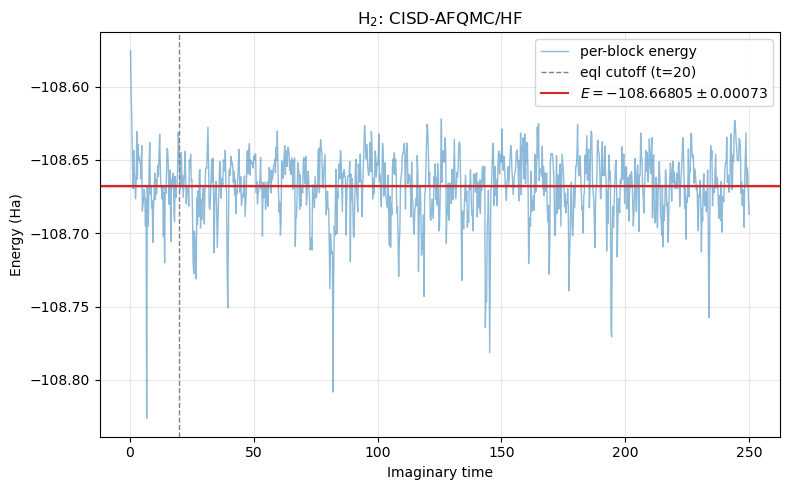

In [23]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
wave = wfn_exp.wfn(    
    guide_overlap_fn=rcisd_wfn.r_overlap,
    force_bias_fn=rcisd_wfn.r_force_bias,
    trial_overlap_fn=rcisd_wfn.r_overlap,
    energy_fn=rcisd_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=ham_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

In [31]:
type(wave.norb)

int

In [36]:
print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data["lci1"] = oe.contract(
      "git,pt->gip",
      ham_data["chol"].reshape(-1, wave.norb, wave.norb)[:, :, wave.nelec[0] :],
      wave_data["ci1"],
      backend="jax"
      )

ham_data = rprop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data = init_prop_data(wave, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = rprop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(rprop, wave, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e
    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * e.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-35-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000   -108.666985      1.88
 5.00    172.765488      0    172.765488   -108.666323      7.50
10.00    170.572578      0    170.572578   -108.667565      8.21
15.00    173.414261      0    173.414261   -108.671098      8.93
20.00    170.337110      0    170.337110   -108.667253      9.66
25.00    174.677046      0    174.677046   -108.667429     10.38
30.00    170.651489      0    170.651489   -108.669200     11.10
35.00    171.353318      0    171.353318   -108.667704     11.82
40.00    168.237810      0    168.237810   -108.668442     12.54
45.00    173.721660      0    173.721660   -108.669123     13.27
50.00   

E = -108.669806 +/- 0.000089 Ha  (averaged over 921 blocks, t >= 20)


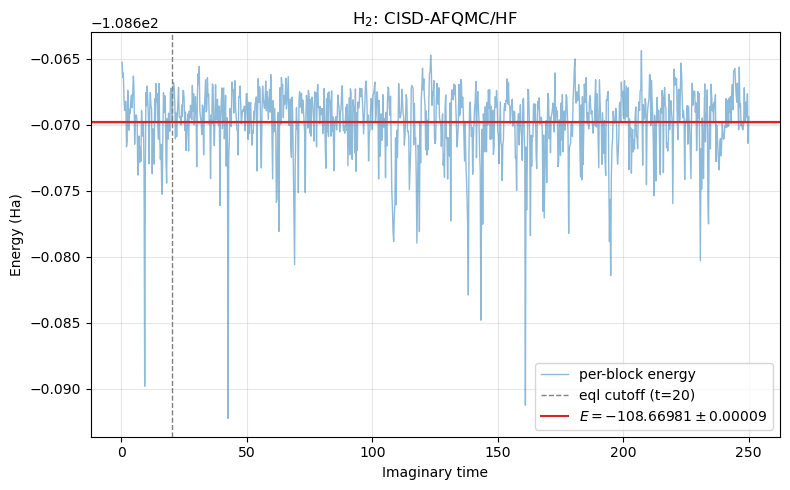

In [37]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
wave = wfn_exp.wfn(    
    guide_overlap_fn=rcisd_wfn.r_overlap,
    force_bias_fn=rcisd_wfn.r_force_bias,
    trial_overlap_fn=rhf_wfn.r_overlap,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=ham_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

In [44]:
print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

# ham_data["lci1"] = oe.contract(
#       "git,pt->gip",
#       ham_data["chol"].reshape(-1, wave.norb, wave.norb)[:, :, wave.nelec[0] :],
#       wave_data["ci1"],
#       backend="jax"
#       )

ham_data = rprop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data = init_prop_data(wave, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = rprop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(rprop, wave, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e
    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * e.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-35-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000   -108.523474      0.81
 5.00    173.025448      0    161.501304   -108.656169      6.00
10.00    170.586790      0    159.229965   -108.651561      6.66
15.00    173.423907      0    161.574759   -108.657311      7.32
20.00    170.396090      0    159.309420   -108.657362      7.99
25.00    174.766866      0    162.971176   -108.661071      8.65
30.00    170.709380      0    160.133271   -108.648556      9.31
35.00    171.447111      0    160.199703   -108.658848      9.97
40.00    168.272570      0    155.318694   -108.680976     10.63
45.00    173.806634      0    163.659067   -108.637817     11.29
50.00   

E = -108.664245 +/- 0.000497 Ha  (averaged over 921 blocks, t >= 20)


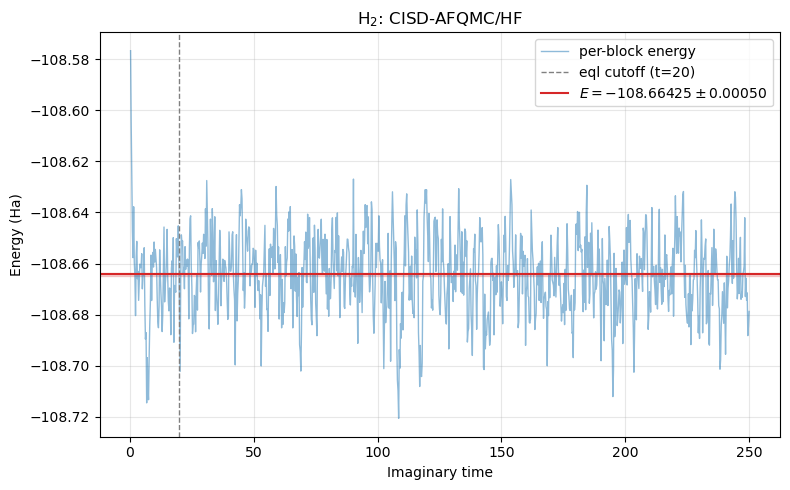

In [45]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()